Importing necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('R:/PROJECTS/User Journey Funnel Analysis/user_journey_funnel_analysis/retail_user_behavior_100k/retail_user_behavior_100k.csv')

In [3]:
df.head(10)

,session_id,user_id,timestamp_utc,event_index,user_action,product_id,category,brand,price,channel,device_type,region,traffic_source,time_spent_sec,session_length,interaction_count,is_conversion,drop_off_flag
0,S0000001,U000372,2026-01-08T02:34:40Z,1,view,P1481,Electronics,Samsung,316.55,mobile,desktop,JP,organic,25,4,1,0,0
1,S0000001,U000372,2026-01-08T02:35:20Z,2,wishlist,P1481,Electronics,Samsung,316.55,mobile,desktop,JP,organic,28,4,2,0,0
2,S0000001,U000372,2026-01-08T02:35:43Z,3,view,P1481,Electronics,Samsung,316.55,mobile,desktop,JP,organic,5,4,3,0,0
3,S0000001,U000372,2026-01-08T02:36:13Z,4,drop,P1481,Electronics,Samsung,316.55,mobile,desktop,JP,organic,16,4,4,0,1
4,S0000002,U004812,2026-01-29T11:07:27Z,1,view,P1836,Groceries,OrganicCo,212.37,mobile,tablet,UK,direct,15,4,1,0,0
5,S0000002,U004812,2026-01-29T11:07:40Z,2,add_to_cart,P1836,Groceries,OrganicCo,212.37,mobile,tablet,UK,direct,6,4,2,0,0
6,S0000002,U004812,2026-01-29T11:08:00Z,3,view,P1836,Groceries,OrganicCo,212.37,mobile,tablet,UK,direct,5,4,3,0,0
7,S0000002,U004812,2026-01-29T11:08:49Z,4,drop,P1836,Groceries,OrganicCo,212.37,mobile,tablet,UK,direct,34,4,4,0,1
8,S0000003,U001935,2026-03-08T08:35:30Z,1,view,P1816,Groceries,FreshFarm,261.82,web,android,AU,organic,27,6,1,0,0
9,S0000003,U001935,2026-03-08T08:35:51Z,2,click,P1816,Groceries,FreshFarm,261.82,web,android,AU,organic,14,6,2,0,0


In [4]:
df.shape #Checking the dimesion of the dataset

(108584, 18)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 108584 entries, 0 to 108583
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   session_id         108584 non-null  str    
 1   user_id            108584 non-null  str    
 2   timestamp_utc      108584 non-null  str    
 3   event_index        108584 non-null  int64  
 4   user_action        108584 non-null  str    
 5   product_id         108584 non-null  str    
 6   category           108584 non-null  str    
 7   brand              108584 non-null  str    
 8   price              108584 non-null  float64
 9   channel            108584 non-null  str    
 10  device_type        108584 non-null  str    
 11  region             108584 non-null  str    
 12  traffic_source     108584 non-null  str    
 13  time_spent_sec     108584 non-null  int64  
 14  session_length     108584 non-null  int64  
 15  interaction_count  108584 non-null  int64  
 16  is_conversion

In [6]:
df.isna().sum() #Cheking the Null values

session_id           0
user_id              0
timestamp_utc        0
event_index          0
user_action          0
product_id           0
category             0
brand                0
price                0
channel              0
device_type          0
region               0
traffic_source       0
time_spent_sec       0
session_length       0
interaction_count    0
is_conversion        0
drop_off_flag        0
dtype: int64

In [7]:
df.duplicated().sum() #Checking the duplicates

np.int64(0)

In [8]:
df.describe()

,event_index,price,time_spent_sec,session_length,interaction_count,is_conversion,drop_off_flag
count,108584.000000,108584.000000,108584.000000,108584.000000,108584.000000,108584.000000,108584.000000
mean,3.834626,249.497547,17.828317,6.669251,3.834626,0.038707,0.127063
std,2.238094,145.627749,9.356853,2.038962,2.238094,0.192897,0.333045
min,1.000000,7.290000,3.000000,3.000000,1.000000,0.000000,0.000000
25%,2.000000,119.950000,11.000000,5.000000,2.000000,0.000000,0.000000
50%,4.000000,253.850000,18.000000,7.000000,4.000000,0.000000,0.000000
75%,5.000000,376.080000,24.000000,8.000000,5.000000,0.000000,0.000000
max,13.000000,499.860000,64.000000,13.000000,13.000000,1.000000,1.000000


Exploratory Data Analysis

In [9]:
print(f'Number of Unique session is : {df['session_id'].nunique()}') #Number of unique sessions

Number of Unique session is : 18000


In [10]:
print(f'Number of Unique user is : {df['user_id'].nunique()}') #Number of unique users

Number of Unique user is : 6806


In [11]:
df['timestamp_utc'].dtype

<StringDtype(na_value=nan)>

In [12]:
#Changing timestamp_utc to date type

df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'])
print(f'Data type of timestamp_utc column is : {df['timestamp_utc'].dtype}')

Data type of timestamp_utc column is : datetime64[us, UTC]


In [13]:
df[['event_index','user_action']].head(10)

,event_index,user_action
0,1,view
1,2,wishlist
2,3,view
3,4,drop
4,1,view
5,2,add_to_cart
6,3,view
7,4,drop
8,1,view
9,2,click


In [14]:
df['user_action'].value_counts()

user_action
view           44245
click          27735
drop           13797
add_to_cart    11642
wishlist        6962
purchase        4203
Name: count, dtype: int64

Text(0, 0.5, 'Values')

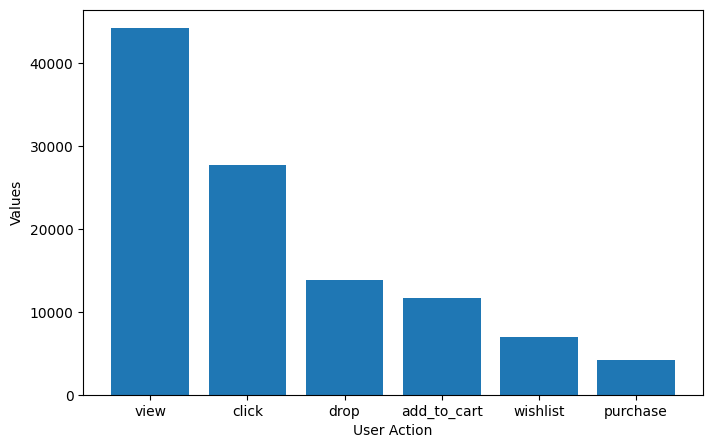

In [15]:
plt.figure(figsize=(8,5))
x = df['user_action'].value_counts().index
y = df['user_action'].value_counts().values

plt.bar(x,y,)
plt.xlabel('User Action')
plt.ylabel('Values')

In [16]:
funnel = df.groupby('user_action')['user_id'].nunique().sort_values(ascending=False)
funnel

user_action
view           6806
click          6353
drop           6278
add_to_cart    5187
wishlist       4014
purchase       3238
Name: user_id, dtype: int64

In [17]:
funnel_viz = {
    'user_action' : funnel.index,
    'user_counts' : funnel.values
}

funnel_viz_df = pd.DataFrame(funnel_viz)

C:\Users\rahul\AppData\Local\Temp\ipykernel_16960\1879464112.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = funnel_viz_df,x='user_action',y='user_counts',palette='viridis')


Text(0, 0.5, 'Number of Unique Users')

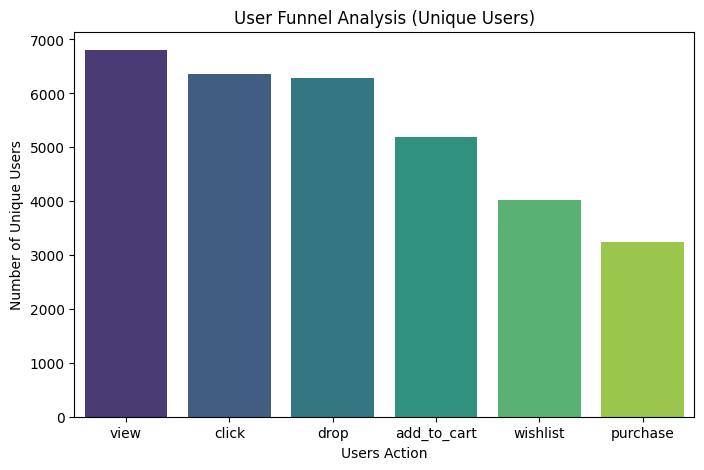

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(data = funnel_viz_df,x='user_action',y='user_counts',palette='viridis')

#Add titles and labels
plt.title('User Funnel Analysis (Unique Users)')
plt.xlabel('Users Action')
plt.ylabel('Number of Unique Users')


In [19]:
#Dividing the entire series by the value of the first step (view)
overall_conversion = (funnel / funnel.iloc[0]) * 100

print(overall_conversion.round(2))

user_action
view           100.00
click           93.34
drop            92.24
add_to_cart     76.21
wishlist        58.98
purchase        47.58
Name: user_id, dtype: float64


In [20]:
funnel_conversion_viz = {
    'user_action' : overall_conversion.index,
    'conversion' : overall_conversion.values
}

funnel_conversion_viz_df = pd.DataFrame(funnel_conversion_viz)

C:\Users\rahul\AppData\Local\Temp\ipykernel_16960\3911536664.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = funnel_conversion_viz_df,x='user_action',y='conversion',palette='viridis')


Text(0, 0.5, 'Percentage of Conversion')

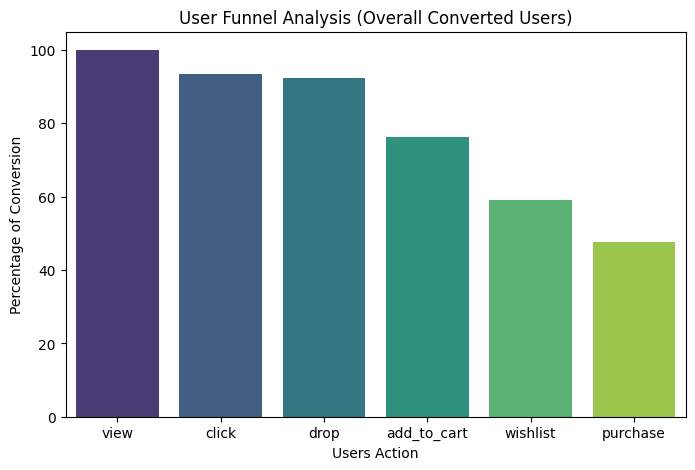

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(data = funnel_conversion_viz_df,x='user_action',y='conversion',palette='viridis')

#Add titles and labels
plt.title('User Funnel Analysis (Overall Converted Users)')
plt.xlabel('Users Action')
plt.ylabel('Percentage of Conversion')


In [22]:
#Shifting the series by 1 to align each step with its previous step
step_conversion = (funnel / funnel.shift(1)) * 100

#Fill the first step with 100% since it has no prior step
step_conversion = step_conversion.fillna(100)

print(step_conversion.round(2))

user_action
view           100.00
click           93.34
drop            98.82
add_to_cart     82.62
wishlist        77.39
purchase        80.67
Name: user_id, dtype: float64


In [23]:
funnel_step_conversion_viz = {
    'user_action' : step_conversion.index,
    'conversion' : step_conversion.values
}

funnel_step_conversion_viz_df = pd.DataFrame(funnel_step_conversion_viz)

C:\Users\rahul\AppData\Local\Temp\ipykernel_16960\3588193549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = funnel_step_conversion_viz_df,x='user_action',y='conversion',palette='viridis')


Text(0, 0.5, 'Percentage of Conversion')

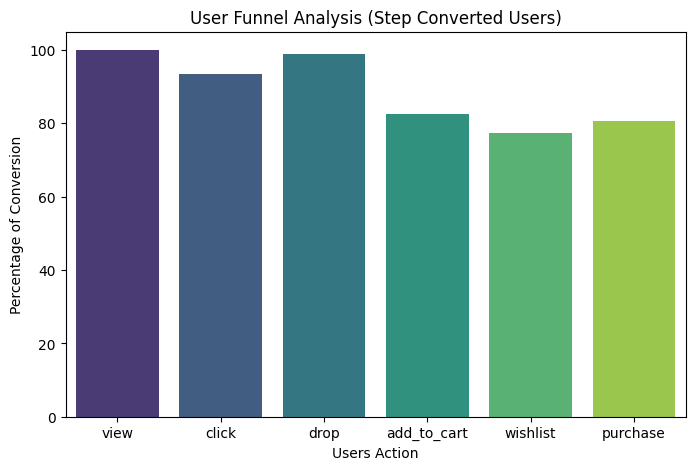

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(data = funnel_step_conversion_viz_df,x='user_action',y='conversion',palette='viridis')

#Add titles and labels
plt.title('User Funnel Analysis (Step Converted Users)')
plt.xlabel('Users Action')
plt.ylabel('Percentage of Conversion')


In [25]:
#Drop-off Analysis
drop_off = (funnel.shift(1)-funnel) 

#Fill the first step with 0 since as no one has drop-off
drop_off = drop_off.fillna(0)

print(drop_off.astype('int64'))

user_action
view              0
click           453
drop             75
add_to_cart    1091
wishlist       1173
purchase        776
Name: user_id, dtype: int64


In [26]:
drop_off_viz = {
    'user_action' : drop_off.index,
    'drop_off' : drop_off.values
}
drop_off_viz_df = pd.DataFrame(drop_off_viz)

C:\Users\rahul\AppData\Local\Temp\ipykernel_16960\2197473392.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = drop_off_viz_df,x='user_action',y='drop_off',palette='viridis')


Text(0, 0.5, 'Number of Drop-offs')

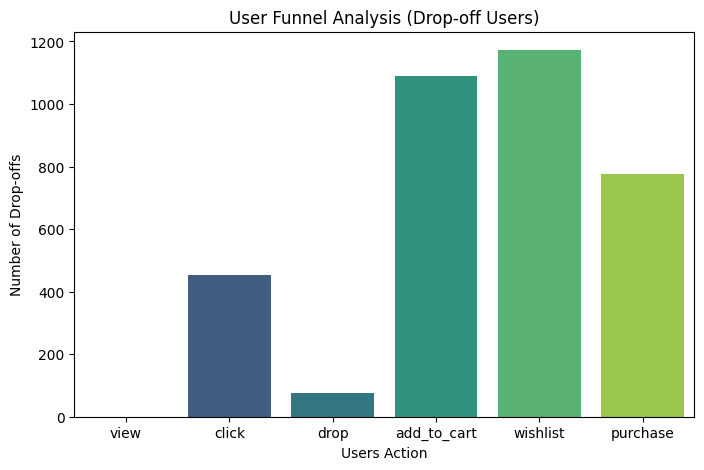

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(data = drop_off_viz_df,x='user_action',y='drop_off',palette='viridis')

#Add titles and labels
plt.title('User Funnel Analysis (Drop-off Users)')
plt.xlabel('Users Action')
plt.ylabel('Number of Drop-offs')


In [28]:
#Subtract each stage count from the very first stage (view)
cumulative_dropoff = funnel.iloc[0] - funnel

print(cumulative_dropoff)

user_action
view              0
click           453
drop            528
add_to_cart    1619
wishlist       2792
purchase       3568
Name: user_id, dtype: int64


In [29]:
cu_drop_off_viz = {
    'user_action' : cumulative_dropoff.index,
    'drop_off' : cumulative_dropoff.values
}
cu_drop_off_viz_df = pd.DataFrame(cu_drop_off_viz)

C:\Users\rahul\AppData\Local\Temp\ipykernel_16960\590034065.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = cu_drop_off_viz_df,x='user_action',y='drop_off',palette='viridis')


Text(0, 0.5, 'Number of Cumulative Drop-off Users')

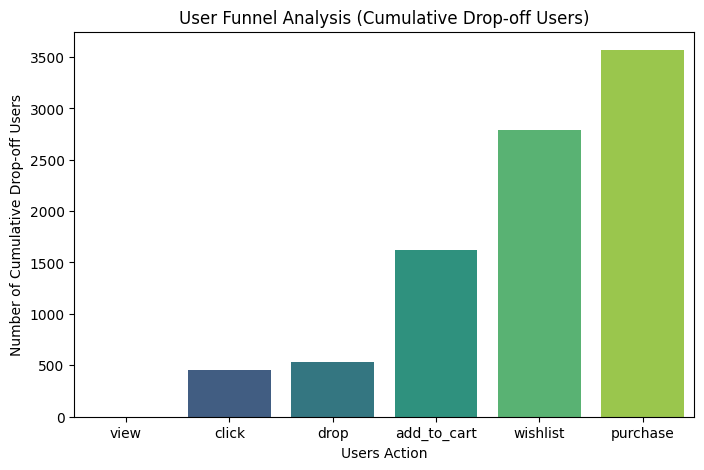

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(data = cu_drop_off_viz_df,x='user_action',y='drop_off',palette='viridis')

#Add titles and labels
plt.title('User Funnel Analysis (Cumulative Drop-off Users)')
plt.xlabel('Users Action')
plt.ylabel('Number of Cumulative Drop-off Users')


In [31]:
#Drop-off rates
drop_off_rates = ((funnel.shift(1) - funnel) / funnel.shift(1)) * 100
drop_off_rates = drop_off_rates.fillna(100)
drop_off_rates

user_action
view           100.000000
click            6.655892
drop             1.180545
add_to_cart     17.378146
wishlist        22.614228
purchase        19.332337
Name: user_id, dtype: float64

In [32]:
drop_off_rates_viz = {
    'user_action' : drop_off_rates.index,
    'drop_off' : drop_off_rates.values
}
drop_off_rates_viz_df = pd.DataFrame(drop_off_rates_viz)

C:\Users\rahul\AppData\Local\Temp\ipykernel_16960\2259987392.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = drop_off_rates_viz_df,x='user_action',y='drop_off',palette='viridis')


Text(0, 0.5, 'Drop-off Rates')

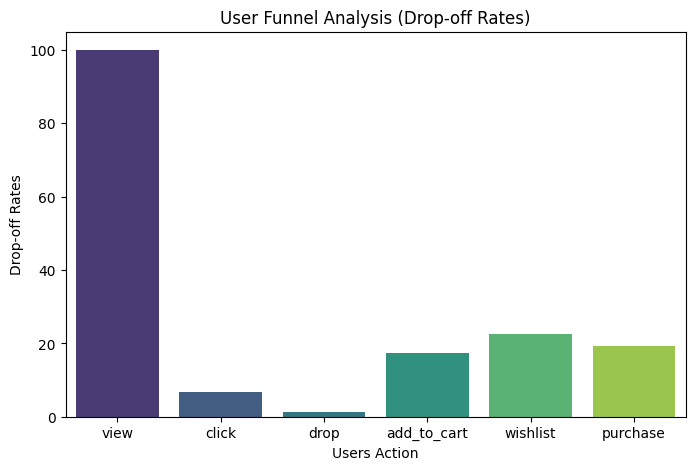

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(data = drop_off_rates_viz_df,x='user_action',y='drop_off',palette='viridis')

#Add titles and labels
plt.title('User Funnel Analysis (Drop-off Rates)')
plt.xlabel('Users Action')
plt.ylabel('Drop-off Rates')


In [44]:
df.groupby('category')['price'].sum().sort_values(ascending=False)

category
Sports         3696347.35
Electronics    3529032.94
Apparel        3443446.02
Accessories    3422532.18
Home           3341256.27
Groceries      3325915.57
Shoes          3263194.88
Beauty         3069716.43
Name: price, dtype: float64

In [46]:
df.columns

Index(['session_id', 'user_id', 'timestamp_utc', 'event_index', 'user_action',
       'product_id', 'category', 'brand', 'price', 'channel', 'device_type',
       'region', 'traffic_source', 'time_spent_sec', 'session_length',
       'interaction_count', 'is_conversion', 'drop_off_flag'],
      dtype='str')

In [54]:
#Group by device and action to find unique users
device_funnel = df.groupby(['device_type', 'user_action'])['user_id'].nunique().reset_index()

#Re-order the user actions so they follow the chronological funnel steps
action_order = ['view', 'click', 'drop', 'add_to_cart', 'wishlist', 'purchase']
device_funnel['user_action'] = pd.Categorical(device_funnel['user_action'], categories=action_order, ordered=True)
device_funnel = device_funnel.sort_values(['device_type', 'user_action']).reset_index(drop=True)

#Calculate conversion rates relative to the 'view' stage for each device
first_stage_counts = device_funnel[device_funnel['user_action'] == 'view'].set_index('device_type')['user_id']
device_funnel['conversion_rate_%'] = device_funnel.apply(
    lambda row: (row['user_id'] / first_stage_counts[row['device_type']]) * 100, axis=1
)

print(device_funnel)

   device_type  user_action  user_id  conversion_rate_%
0      android         view     3449         100.000000
1      android        click     2862          82.980574
2      android         drop     2774          80.429110
3      android  add_to_cart     1968          57.060017
4      android     wishlist     1348          39.083792
5      android     purchase     1048          30.385619
6      desktop         view     3375         100.000000
7      desktop        click     2780          82.370370
8      desktop         drop     2773          82.162963
9      desktop  add_to_cart     1929          57.155556
10     desktop     wishlist     1316          38.992593
11     desktop     purchase      973          28.829630
12         ios         view     3335         100.000000
13         ios        click     2775          83.208396
14         ios         drop     2669          80.029985
15         ios  add_to_cart     1910          57.271364
16         ios     wishlist     1298          38

In [72]:
mobile_device_funnel = device_funnel[device_funnel['device_type'].isin(['ios', 'android'])]
desktop_device_funnel = device_funnel[device_funnel['device_type'].isin(['desktop'])]
desktop_device_funnel

,device_type,user_action,user_id,conversion_rate_%
6,desktop,view,3375,100.000000
7,desktop,click,2780,82.370370
8,desktop,drop,2773,82.162963
9,desktop,add_to_cart,1929,57.155556
10,desktop,wishlist,1316,38.992593
11,desktop,purchase,973,28.829630


In [69]:
#Sum up all unique users who purchased
total_mob_purchases = mobile_device_funnel[mobile_device_funnel['user_action'] == 'purchase']['user_id'].sum()

#Sum up all unique users who viewed
total_mob_views = mobile_device_funnel[mobile_device_funnel['user_action'] == 'view']['user_id'].sum()

#Calculate the true blended rate
mob_weighted_avg_purchase = (total_mob_purchases / total_mob_views) * 100

print(f'Total Purchases: {total_purchases}')
print(f'Total Views: {total_views}')
print(f"Weighted-Average Purchase Rate: {mob_weighted_avg_purchase:.2f}%")

Total Purchases: 2039
Total Views: 6784
Weighted-Average Purchase Rate: 30.06%


In [73]:
#Sum up all unique users who purchased
total_desk_purchases = desktop_device_funnel[desktop_device_funnel['user_action'] == 'purchase']['user_id'].sum()

#Sum up all unique users who viewed
total_desk_views = desktop_device_funnel[desktop_device_funnel['user_action'] == 'view']['user_id'].sum()

#Calculate the true blended rate
desk_weighted_avg_purchase = (total_desk_purchases / total_desk_views) * 100

print(f'Total Purchases: {total_desk_purchases}')
print(f'Total Views: {total_desk_views}')
print(f"Weighted-Average Purchase Rate: {desk_weighted_avg_purchase:.2f}%")

Total Purchases: 973
Total Views: 3375
Weighted-Average Purchase Rate: 28.83%


In [95]:
region_purchases = df[df['user_action'] == 'purchase'].groupby('region')['price'].sum().reset_index()

region_purchases = region_purchases.sort_values(by='price', ascending=False)

print(region_purchases)

  region      price
6     JP  125138.00
3     DE  120971.75
2     CA  118907.01
1     BR  118503.57
7     UK  117478.96
8     US  117365.22
4     FR  112238.30
0     AU  110167.82
5     IN  103695.96


In [97]:
#Get total unique users who viewed (the baseline) per country
country_views = df[df['user_action'] == 'view'].groupby('region')['user_id'].nunique()

#Get total unique users who purchased per country
country_purchases = df[df['user_action'] == 'purchase'].groupby('region')['user_id'].nunique()

#Combine counts and compute conversion rate
country_analysis = pd.DataFrame({
    'Views': country_views,
    'Purchases': country_purchases
}).fillna(0) # Handles any countries with 0 purchases

country_analysis['Conversion_Rate_%'] = (country_analysis['Purchases'] / country_analysis['Views']) * 100

#Extract the exact countries with the max and min rates
highest_country = country_analysis['Conversion_Rate_%'].idxmax()
highest_rate = country_analysis['Conversion_Rate_%'].max()

lowest_country = country_analysis['Conversion_Rate_%'].idxmin()
lowest_rate = country_analysis['Conversion_Rate_%'].min()

print(f"Highest Conversion Country: {highest_country} ({highest_rate:.2f}%)")
print(f"Lowest Conversion Country: {lowest_country} ({lowest_rate:.2f}%)")

Highest Conversion Country: JP (27.03%)
Lowest Conversion Country: IN (24.61%)
